In [1]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
import os

folder_path = 'datasets/retrofit/resampled'

dfs = []

for filename in os.listdir(folder_path):
    if filename.endswith('.csv'):
        file_path = os.path.join(folder_path, filename)
        df = pd.read_csv(file_path)
       
        df['timestamp'] = pd.to_datetime(df['timestamps'])
        
        df.drop(columns=['timestamps'], inplace=True)
        df.set_index('timestamp', inplace=True)
        df.sort_index(inplace=True)
        dfs.append(df)
dfs[0].head()  



,total_energy,pump_energy,hvac_energy,Tin,Tout,RH,month,PMV,PPD,Overall_Comfort
timestamp,,,,,,,,,,
2022-08-14 13:30:00,17.923451,0.0,0.0,26.663333,25.855000,43.000000,8,0.36,7.7,92.3
2022-08-14 13:45:00,9.999323,0.0,0.0,26.565926,25.663333,43.093333,8,0.33,7.3,92.7
2022-08-14 14:00:00,24.090146,0.0,0.0,26.500000,26.318667,43.490000,8,0.31,7.0,93.0
2022-08-14 14:15:00,40.105616,0.0,0.0,26.444444,26.343333,43.593333,8,0.29,6.8,93.2
2022-08-14 14:30:00,221.178375,0.0,0.0,26.332222,26.945333,43.990000,8,0.26,6.4,93.6


In [ ]:
from sklearn.preprocessing import MinMaxScaler
import torch
import torch.nn as nn

test_start = pd.Timestamp('2023-01-22')
test_end = pd.Timestamp('2023-02-27')

df = dfs[0].copy()
# df = df.dropna()

unique_days = df.index.normalize().unique()
second_day = unique_days[4]

start = pd.to_datetime('2023-02-02 00:00:00')
end   = pd.to_datetime('2023-02-02 23:59:59')
df_day = df[(df.index >= start) & (df.index <= end)]

print(df_day.shape[0])
lags_out = [1, 2, 3, 4, 96]
for lag in lags_out:
    df[f'Tout_lag{lag}'] = df['Tout'].shift(lag)

df['Tin_lag4'] = df['Tin'].shift(4)
df['Tin_lag1'] = df['Tin'].shift(1)
df['Tin_lag2'] = df['Tin'].shift(2)
df['Tin_lag3'] = df['Tin'].shift(3)
future_steps = 4
for i in range(1, future_steps + 1):
    df[f'Tout_fut{i}'] = df['Tout'].shift(-i)

df['Tin_target']  = df['Tin'].shift(-1).dropna()          
df['is_test'] = (df.index >= test_start) & (df.index <= test_end)
df['mode_heatcool'] = np.where(df['Tout'] > 15, 0, 1)

df['hvac_mode'] = 0 
on_mask = df['hvac_energy'] > 0
nonzero_power = df.loc[on_mask, 'hvac_energy']
bins = pd.qcut(nonzero_power, q=2, labels=[1, 2])
df.loc[on_mask, 'hvac_mode'] = bins.astype(int).values
df['hvac_mode_lag'] = df['hvac_mode'].shift(1)

df_on = df[df['hvac_energy'] > 0].copy()
nonzero_power = df_on['hvac_energy']
df_off = df[df.hvac_mode == 0].copy()

96


In [ ]:
# from sklearn.model_selection import train_test_split
# from sklearn.metrics import mean_absolute_error, root_mean_squared_error
# from torch.utils.data import Dataset, DataLoader
from sklearn.linear_model import LinearRegression
# from sklearn.linear_model import Ridge

# feature_cols =  ['Tin', 'Tin_lag1','Tin_lag2','Tin_lag3', 'Tin_lag4', 'Tout']
# df_lr = (
#     df
#     .loc[df.hvac_mode==0, ['Tin_target', 'is_test'] + feature_cols]
#     .dropna(subset=['Tin_target'] + feature_cols)
# )

# df_lr_train = df_lr[~df_lr['is_test']]
# df_lr_test = df_lr[df_lr['is_test']]

# X_train = df_lr_train[feature_cols]
# X_test = df_lr_test[feature_cols]
# y_train = df_lr_train['Tin_target']
# y_test = df_lr_test['Tin_target']

# lr = LinearRegression()
# lr.fit(X_train, y_train)

# y_pred = lr.predict(X_test)
# mae = mean_absolute_error(y_test, y_pred)
# rmse = np.sqrt(((y_test - y_pred)**2).mean())

# print(f"LinearReg (HVAC off) → MAE: {mae:.3f} °C, RMSE: {rmse:.3f} °C")

LinearReg (HVAC off) → MAE: 0.071 °C, RMSE: 0.095 °C


NaN rows in inputs/target: 949
Rows before drop: 18430, after drop: 17481
Epoch 1: Loss = 2.4934
Epoch 2: Loss = 2.0469
Epoch 3: Loss = 2.7576
Epoch 4: Loss = 2.3284
Epoch 5: Loss = 3.4081
Epoch 6: Loss = 2.8363
Epoch 7: Loss = 0.5248
Epoch 8: Loss = 0.1031
Epoch 9: Loss = 0.0336
Epoch 10: Loss = 0.1338
Epoch 11: Loss = 0.0291
Epoch 12: Loss = 0.1932
Epoch 13: Loss = 0.0426
Epoch 14: Loss = 0.0424
Epoch 15: Loss = 0.0207
LSTM RMSE on HVAC-off: 0.197


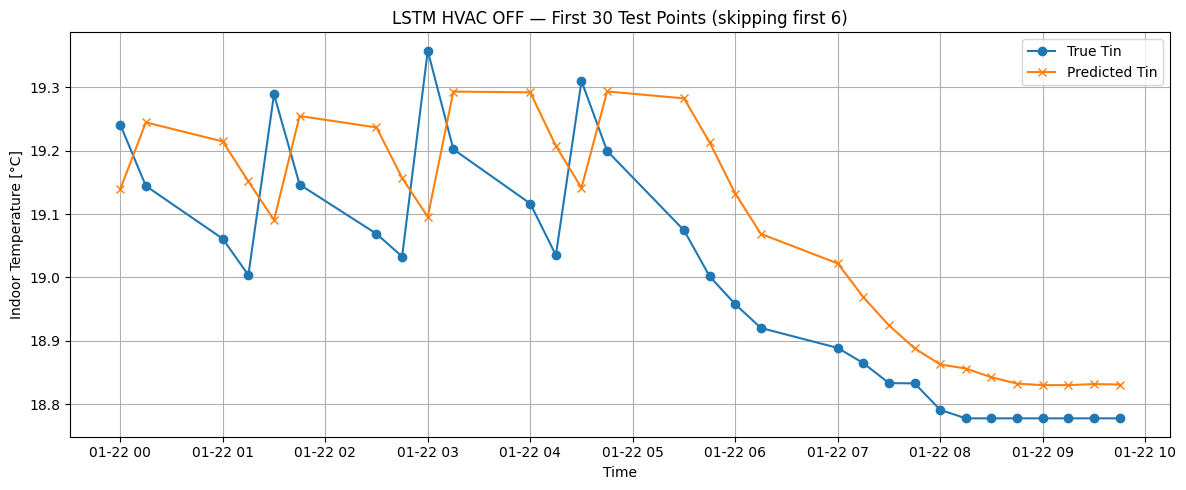

In [14]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import root_mean_squared_error
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler


class HVACOffDataset(Dataset):
    def __init__(self, df, input_cols, target_col='Tin_target', window_size=16):
        
        self.X_seq = []
        self.y = []
        self.is_test_flags = []

        data = df[input_cols + [target_col, 'is_test']].copy()

        arr = data[input_cols].values
        target_Tin = data[target_col].values
        flags = data['is_test'].values


        for i in range(window_size, len(data)):
            self.X_seq.append(arr[i - window_size:i])
            self.y.append(target_Tin[i])
            self.is_test_flags.append(flags[i])

        self.X_seq = torch.tensor(self.X_seq, dtype=torch.float32)
        self.y = torch.tensor(self.y, dtype=torch.float32)
        self.is_test_flags = np.array(self.is_test_flags)

    def __len__(self): return len(self.y)
    def __getitem__(self, idx): return self.X_seq[idx], self.y[idx]

class LSTMWithFuture(nn.Module):
    def __init__(self, input_size, hidden_size=128, num_layers=3):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x_seq):
        _, (hn, _) = self.lstm(x_seq)
        return self.fc(hn[-1]).squeeze()

def train_lstm_model(df_off, input_cols, target_col='Tin_target', window_size=6, batch_size=64, scaler=None):
    dataset = HVACOffDataset(df_off, input_cols, target_col, window_size)

    test_idx = np.where(dataset.is_test_flags == True)[0]
    train_idx = np.where(dataset.is_test_flags == False)[0]
    
    train_ds = torch.utils.data.Subset(dataset, train_idx)
    test_ds = torch.utils.data.Subset(dataset, test_idx)

    train_dl = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    test_dl = DataLoader(test_ds, batch_size=batch_size, shuffle=False)

    model = LSTMWithFuture(input_size=len(input_cols))
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    loss_fn = nn.MSELoss()

    for epoch in range(15):
        model.train()
        for xb_seq, yb in train_dl:
            optimizer.zero_grad()
            pred = model(xb_seq)
            loss = loss_fn(pred, yb)
            loss.backward()
            optimizer.step()
        print(f"Epoch {epoch+1}: Loss = {loss.item():.4f}")

    model.eval()
    test_timestamps = [df_off.iloc[i].name for i in test_idx]

    preds, actuals, times = [], [], []

    with torch.no_grad():
        batch_start = 0
        for xb_seq, yb in test_dl:
            out = model(xb_seq)
            preds.extend(out.numpy())
            actuals.extend(yb.numpy())

            batch_size = len(xb_seq)
            times.extend(test_timestamps[batch_start:batch_start + batch_size])
            batch_start += batch_size
            
    rmse = root_mean_squared_error(actuals, preds)
    print(f"LSTM RMSE on HVAC-off: {rmse:.3f}")
    results = pd.DataFrame({
    'Tin_true': actuals,
    'Tin_pred': preds
    }, index=pd.to_datetime(times))

    N_skip = 6
    N_plot = 30
    plot_results = results.iloc[N_skip:N_skip+N_plot]

    plt.figure(figsize=(12, 5))
    plt.plot(plot_results.index, plot_results['Tin_true'], label='True Tin', marker='o')
    plt.plot(plot_results.index, plot_results['Tin_pred'], label='Predicted Tin', marker='x')
    plt.xlabel('Time')
    plt.ylabel('Indoor Temperature [°C]')
    plt.title(f'LSTM HVAC OFF — First {N_plot} Test Points (skipping first {N_skip})')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    return model, scaler, dataset

input_cols = ['Tin', 'Tout', 'Tin_lag1', 'Tin_lag2', 'Tin_lag3', 'Tin_lag4', 'Tout_lag1', 'Tout_lag2', 'Tout_fut1', 'Tout_fut2']

target_col = 'Tin_target'

original_rows = len(df_off)

required_cols = input_cols + [target_col]

nan_mask = df_off[required_cols].isnull().any(axis=1)
num_nans = nan_mask.sum()

print(f"NaN rows in inputs/target: {num_nans}")
print(f"Rows before drop: {original_rows}, after drop: {original_rows - num_nans}")

df_clean = df_off[~nan_mask].copy()
scaler = StandardScaler()
scaler.fit(df_clean[df_clean['is_test'] == False][input_cols])

df_scaled = df_clean.copy()
df_scaled[input_cols] = scaler.transform(df_scaled[input_cols])

model, scaler, dataset = train_lstm_model(df_scaled, input_cols, scaler=scaler)

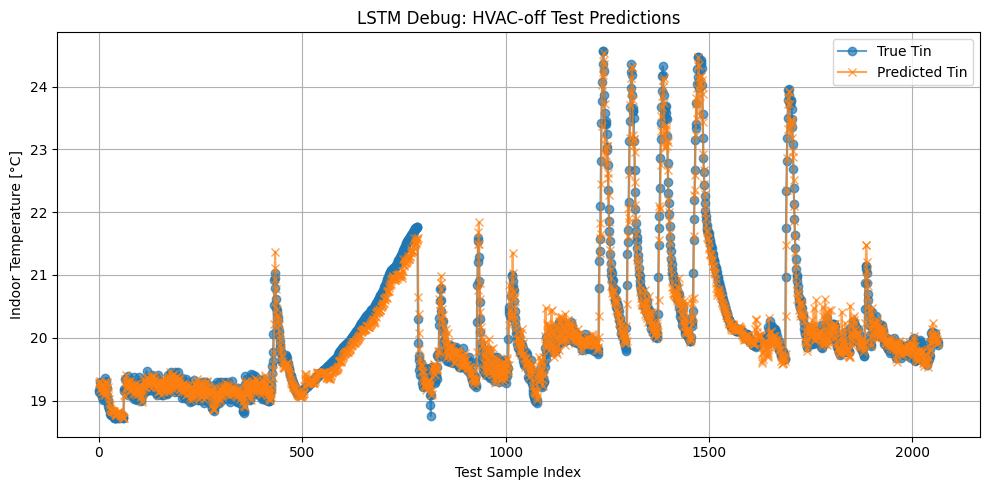

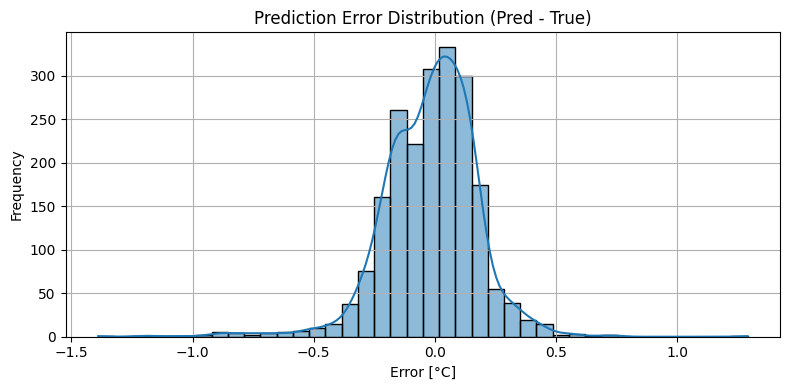

Mean error: -0.018 °C
RMSE: 0.197 °C
Predicted Tin range: 18.72 – 24.53
True Tin range: 18.72 – 24.57


In [16]:
import seaborn as sns

def debug_plot_lstm_predictions(model, dataset, df_raw, input_cols, title='LSTM Debug: HVAC-off Test Predictions'):
    model.eval()

    # Get test indices
    test_idx = np.where(dataset.is_test_flags == True)[0]
    if len(test_idx) == 0:
        print("No test data in dataset.")
        return

    # Get X and y for test set
    test_X = dataset.X_seq[test_idx]
    test_y = dataset.y[test_idx]

    # Predict
    with torch.no_grad():
        pred_y = model(test_X).numpy()
        true_y = test_y.numpy()

    # Plot predicted vs true
    plt.figure(figsize=(10, 5))
    plt.plot(true_y, label='True Tin', marker='o', alpha=0.7)
    plt.plot(pred_y, label='Predicted Tin', marker='x', alpha=0.7)
    plt.xlabel('Test Sample Index')
    plt.ylabel('Indoor Temperature [°C]')
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # Plot error distribution
    errors = pred_y - true_y
    plt.figure(figsize=(8, 4))
    sns.histplot(errors, bins=40, kde=True)
    plt.title("Prediction Error Distribution (Pred - True)")
    plt.xlabel("Error [°C]")
    plt.ylabel("Frequency")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # Print some stats
    print(f"Mean error: {np.mean(errors):.3f} °C")
    print(f"RMSE: {np.sqrt(np.mean(errors**2)):.3f} °C")
    print(f"Predicted Tin range: {pred_y.min():.2f} – {pred_y.max():.2f}")
    print(f"True Tin range: {true_y.min():.2f} – {true_y.max():.2f}")

debug_plot_lstm_predictions(model, dataset, df_raw=df_off, input_cols=input_cols)

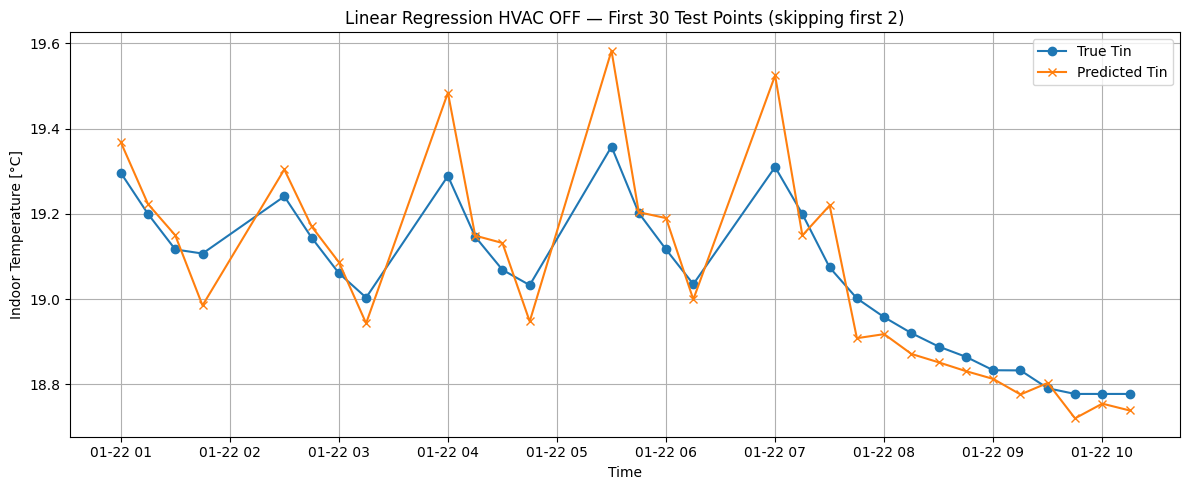

In [ ]:
# results = pd.DataFrame({
#     'Tin_true': y_test.values,
#     'Tin_pred': y_pred,
# }, index=df_lr_test.index)

# N_skip = 2
# N_plot = 30
# plot_results = results.iloc[N_skip:N_skip+N_plot]

# plt.figure(figsize=(12, 5))
# plt.plot(plot_results.index, plot_results['Tin_true'], label='True Tin', marker='o')
# plt.plot(plot_results.index, plot_results['Tin_pred'], label='Predicted Tin', marker='x')
# plt.xlabel('Time')
# plt.ylabel('Indoor Temperature [°C]')
# plt.title(f'Linear Regression HVAC OFF — First {N_plot} Test Points (skipping first {N_skip})')
# plt.legend()
# plt.grid(True)
# plt.tight_layout()
# plt.show()



In [4]:
from xgboost import XGBRegressor
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV

feature_cols = [
    'Tin',        
    'hvac_mode',
    # 'hvac_mode_lag',
    'Tin_lag1',
    'Tin_lag2',
    'Tin_lag3',
    'Tin_lag4',
    'Tout'
    # 'mode_heatcool',
    # 'Tin_lag2',
    # 'Tout'
]


df_on['Tin_target'] = df_on['Tin'].shift(-1)
df_on = df_on.dropna()
target_col = 'Tin_target'  

df_on_train = df_on[~df_on['is_test']]
df_on_test = df_on[df_on['is_test']]

X_train = df_on_train[feature_cols]
X_test = df_on_test[feature_cols]
y_train = df_on_train[target_col]
y_test = df_on_test[target_col]

# print(df_on.head(50))
# param_grid = {
#     'n_estimators': [100, 120, 160, 200, 300],
#     'max_depth': [4, 6, 8, 10, 12],
#     'learning_rate': [0.05, 0.07, 0.1, 0.2],
#     'subsample': [0.8, 1.0],
#     'colsample_bytree': [0.8, 1.0]
# }

param_grid = {
    'n_estimators': [60, 80, 100, 120, 160],
    'max_depth': [6, 8, 10, 12],
    'min_samples_leaf': [1, 3, 5, 7],
    'min_samples_split': [2, 5]
}

tscv = TimeSeriesSplit(n_splits=5)
rf = RandomForestRegressor(random_state=42, n_jobs=-1)
# rf = RandomForestRegressor(n_estimators=8, max_depth=9, random_state=42)
# grid = GridSearchCV(
#     xg,
#     param_grid,
#     cv=tscv,
#     scoring='neg_mean_absolute_error',
#     verbose=2,
#     n_jobs=-1
# )
grid = GridSearchCV(
    rf,
    param_grid,
    cv=tscv,
    scoring='neg_mean_absolute_error', 
    verbose=2,
    n_jobs=-1
)
# xg = XGBRegressor(
#     n_estimators=200,
#     max_depth=10,
#     learning_rate=0.04,
#     subsample=0.8,
#     colsample_bytree=0.8,
#     random_state=42
# )
grid.fit(X_train, y_train)
print("Best Params:", grid.best_params_)
print("Best CV MAE:", -grid.best_score_)
# xg.fit(X_train, y_train)
# rf.fit(X_train, y_train)

# y_pred = rf.predict(X_test)
# y_pred_xg = xg.predict(X_test)

y_true = y_test.values

y_pred = grid.best_estimator_.predict(X_test)
mae = np.mean(np.abs(y_pred - y_test))
mape = np.mean(np.abs((y_pred - y_test) / y_test)) * 100
print(f"Test MAE: {mae:.3f} °C")
print(f"Test MAPE: {mape:.3f} %")


Fitting 5 folds for each of 160 candidates, totalling 800 fits
Best Params: {'max_depth': 12, 'min_samples_leaf': 7, 'min_samples_split': 5, 'n_estimators': 100}
Best CV MAE: 0.15654755195646364
Test MAE: 0.085 °C
Test MAPE: 0.422 %


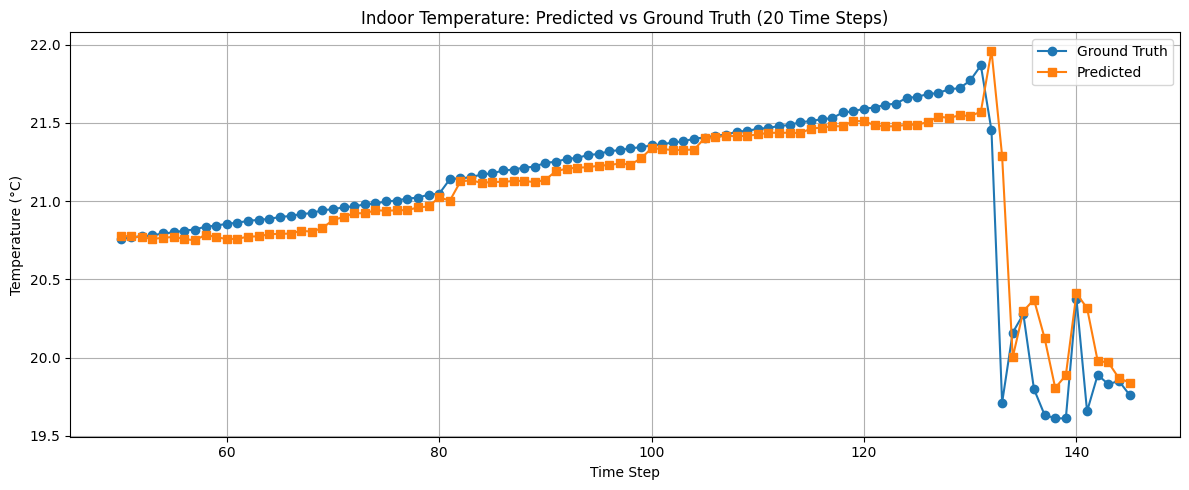

In [ ]:
import matplotlib.pyplot as plt

start_idx = 50
end_idx = start_idx + 96
y_true = y_test.values

y_plot = y_true[start_idx:end_idx]
y_pred_xg_plot = y_pred[start_idx:end_idx]

time_steps = list(range(start_idx, end_idx))

plt.figure(figsize=(12, 5))
plt.plot(time_steps, y_plot, label="Ground Truth", marker='o')
plt.plot(time_steps, y_pred_xg_plot, label="Predicted", marker='s')
plt.title("Indoor Temperature: Predicted vs Ground Truth (20 Time Steps)")
plt.xlabel("Time Step")
plt.ylabel("Temperature (°C)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
def predict_Tin_sequence_full(
    df_test,               
    window_start_idx,      
    lstm_model,               
    rf_model,   
    scaler,
    window_size=6,       
    n_steps=96              
):
    
    lstm_model.eval()
    results = []

    window_df = df_test.iloc[window_start_idx - window_size:window_start_idx].copy()

    assert len(window_df) == window_size
    input_seq = window_df[input_cols].values.tolist()
    input_seq = scaler.transform(window_df[input_cols].values).tolist()

    print("Input sequence:", input_seq)
    idxs = np.arange(window_start_idx, window_start_idx + n_steps)
    results = []

    lag_buffer = [
        df_test['Tin'].iloc[window_start_idx - 0], 
        df_test['Tin'].iloc[window_start_idx - 1],  
        df_test['Tin'].iloc[window_start_idx - 2], 
        df_test['Tin'].iloc[window_start_idx - 3],  
        df_test['Tin'].iloc[window_start_idx - 4],  
    ]

    pred_tin_buffer = lag_buffer.copy() 

    for step in range(n_steps):
        idx = window_start_idx + step
        next_row = df_test.iloc[idx]

        X_feat = lag_buffer.copy()
        hvac_mode = df_test['hvac_mode'].iloc[idx]
        Tout = df_test['Tout'].iloc[idx]

        if hvac_mode == 0:

            predicted_input_row = [
                pred_tin_buffer[0],       
                next_row['Tout'],          
                pred_tin_buffer[1],        
                pred_tin_buffer[2],
                pred_tin_buffer[3],
                pred_tin_buffer[4],
                next_row['Tout_lag1'],     
                next_row['Tout_lag2'],
                next_row['Tout_fut1'],     
                next_row['Tout_fut2'],
            ]

            print(f"\n=== Step {step} ===")
            print(f"Timestamp: {df_test.index[idx]}")
            print(f"HVAC mode: {hvac_mode}")
            print("  pred_tin_buffer:", pred_tin_buffer)
            print("  predicted_input_row (raw):", predicted_input_row)
            scaled_input_row = scaler.transform([predicted_input_row])[0]

            print("  Step 2 input row (raw):", predicted_input_row)
            print("  Step 2 input row (scaled):", scaled_input_row)
            print(f"  Tin_target (true next Tin): {df_test['Tin_target'].iloc[idx]:.3f}")


            input_seq = input_seq[1:] + [scaled_input_row.tolist()]
            x_seq = torch.tensor([input_seq], dtype=torch.float32)
            print("  LSTM input shape:", x_seq.shape)
            with torch.no_grad():
                Tin_pred = lstm_model(x_seq).item()
            print(f"  LSTM Tin_pred: {Tin_pred:.3f}")

            Tin_mean = scaler.mean_[0]
            Tin_std = np.sqrt(scaler.var_[0])
            Tin_pred_scaled = (Tin_pred - Tin_mean) / Tin_std
            pred_tin_buffer = [Tin_pred] + pred_tin_buffer[:-1]

        else:
            Tin_pred = rf_model.predict([X_feat + [hvac_mode] + [Tout]])[0]
            pred_tin_buffer = [Tin_pred] + pred_tin_buffer[:-1]

        results.append({
            'timestamp': df_test.index[idx],
            'Tin_pred': Tin_pred,
            'Tin_true': next_row['Tin'],
            'hvac_mode': hvac_mode,
            'Tin_target': next_row['Tin_target'],
        })

        lag_buffer = [Tin_pred] + lag_buffer[:-1]

    return pd.DataFrame(results).set_index('timestamp')

c:\Users\Kelsier\.conda\envs\thesis\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\Kelsier\.conda\envs\thesis\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\Kelsier\.conda\envs\thesis\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
c:\Users\Kelsier\.conda\envs\thesis\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
c:\Users\Kelsier\.conda\envs\thesis\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted wi

Input sequence: [[-0.8831212473124036, -1.1631277095423316, -0.7678681230604579, -0.6999706288236124, -0.8842216908404618, -0.9451208716609144, -1.1594739602106312, -1.1466726174405024, -1.1776171897059284, -1.1771316960390004], [-0.9371339516850944, -1.1768353294063096, -0.8838649784639212, -0.7577748442517318, -0.6993495519298075, -0.8853219974989539, -1.1622651603507759, -1.1582584440933632, -1.176830837083706, -1.169964844665731], [-0.9426035747246139, -1.1760495422803492, -0.9380883575734321, -0.8736117537463739, -0.7572365007398044, -0.7001975639337666, -1.1759594860383598, -1.1610460114083374, -1.169666290970122, -1.1608751795093897], [-0.7716773211419268, -1.168890148466042, -0.9435793146936597, -0.9277603652458417, -0.8732392040125949, -0.7581635109521364, -1.175174460998944, -1.1747225135474286, -1.160579549557772, -1.1646334064490307], [-0.7327061134585412, -1.1598099416771648, -0.7719863690075611, -0.9332437509873123, -0.927465316741344, -0.8743245228923094, -1.168022010639

c:\Users\Kelsier\.conda\envs\thesis\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
c:\Users\Kelsier\.conda\envs\thesis\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\Kelsier\.conda\envs\thesis\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\Kelsier\.conda\envs\thesis\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\Kelsier\.conda\envs\thesis\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted wi


=== Step 29 ===
Timestamp: 2023-01-23 08:15:00
HVAC mode: 0
  pred_tin_buffer: [np.float64(19.512455786471058), np.float64(19.434846930940747), np.float64(19.362009879713614), 19.205890655517578, 19.231019973754883]
  predicted_input_row (raw): [np.float64(19.512455786471058), np.float64(0.1793333333333333), np.float64(19.434846930940747), np.float64(19.362009879713614), 19.205890655517578, 19.231019973754883, np.float64(0.2553333333333333), np.float64(0.3433333333333334), np.float64(0.1833333333333333), np.float64(0.114)]
  Step 2 input row (raw): [np.float64(19.512455786471058), np.float64(0.1793333333333333), np.float64(19.434846930940747), np.float64(19.362009879713614), 19.205890655517578, 19.231019973754883, np.float64(0.2553333333333333), np.float64(0.3433333333333334), np.float64(0.1833333333333333), np.float64(0.114)]
  Step 2 input row (scaled): [-0.6935912  -1.17212061 -0.74153736 -0.77641233 -0.87234579 -0.85788466
 -1.16130569 -1.14858907 -1.17237484 -1.18176393]
  Tin_ta

c:\Users\Kelsier\.conda\envs\thesis\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\Kelsier\.conda\envs\thesis\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\Kelsier\.conda\envs\thesis\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
c:\Users\Kelsier\.conda\envs\thesis\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
c:\Users\Kelsier\.conda\envs\thesis\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted wi


=== Step 60 ===
Timestamp: 2023-01-23 16:00:00
HVAC mode: 0
  pred_tin_buffer: [np.float64(19.39613546136563), np.float64(19.349328084074497), 19.28148078918457, 19.322511672973633, 19.377052307128906]
  predicted_input_row (raw): [np.float64(19.39613546136563), np.float64(-0.244), np.float64(19.349328084074497), 19.28148078918457, 19.322511672973633, 19.377052307128906, np.float64(-0.362), np.float64(-0.318), np.float64(-0.2213333333333333), np.float64(-0.2226666666666666)]
  Step 2 input row (raw): [np.float64(19.39613546136563), np.float64(-0.244), np.float64(19.349328084074497), 19.28148078918457, 19.322511672973633, 19.377052307128906, np.float64(-0.362), np.float64(-0.318), np.float64(-0.2213333333333333), np.float64(-0.2226666666666666)]
  Step 2 input row (scaled): [-0.76516713 -1.22756225 -0.79436532 -0.82608935 -0.8003013  -0.76754776
 -1.24207604 -1.23500366 -1.22540995 -1.22590125]
  Tin_target (true next Tin): 19.289
  LSTM input shape: torch.Size([1, 6, 10])
  LSTM Tin_p

c:\Users\Kelsier\.conda\envs\thesis\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\Kelsier\.conda\envs\thesis\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\Kelsier\.conda\envs\thesis\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
c:\Users\Kelsier\.conda\envs\thesis\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
c:\Users\Kelsier\.conda\envs\thesis\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted wi

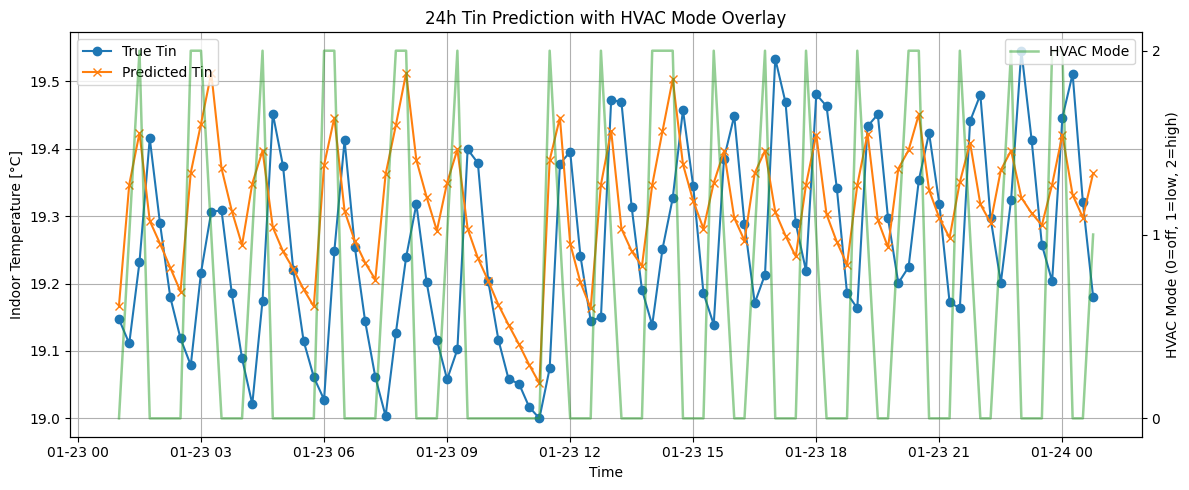

In [36]:
df_test = df[df['is_test']].copy()
# unique_days = df_test.index.normalize().unique()

# second_day = unique_days[4]

# start = pd.to_datetime('2023-02-02 00:00:00')
# end   = pd.to_datetime('2023-02-02 23:59:59')
# df_day = df_test[(df_test.index >= start) & (df_test.index <= end)]
# df_day2 = df[(df.index >= start) & (df.index <= end)]

# target_date = pd.to_datetime('2023-02-02').date()
# df_day = df_test[df_test.index.date == target_date]

# second_day_mask = df_test.index.normalize() == second_day
# df_second_day = df_test[second_day_mask]

# window_length = 96  

# window_start_idx = df_test.index.get_loc(df_second_day.index[4])  

results_24h = predict_Tin_sequence_full(
    df_test=df_test,
    window_start_idx=100,
    lstm_model=model,
    rf_model=grid.best_estimator_,
    scaler=scaler,
    n_steps=96
)


fig, ax1 = plt.subplots(figsize=(12, 5))

ax1.plot(results_24h.index, results_24h['Tin_true'], label='True Tin', marker='o', color='tab:blue')
ax1.plot(results_24h.index, results_24h['Tin_pred'], label='Predicted Tin', marker='x', color='tab:orange')
ax1.set_xlabel('Time')
ax1.set_ylabel('Indoor Temperature [°C]')
ax1.legend(loc='upper left')
ax1.grid(True)

ax2 = ax1.twinx()
ax2.plot(results_24h.index, results_24h['hvac_mode'], label='HVAC Mode', color='tab:green', linewidth=1.8, alpha=0.5)
ax2.set_ylabel('HVAC Mode (0=off, 1=low, 2=high)')
ax2.set_yticks([0,1,2])
ax2.legend(loc='upper right')

plt.title('24h Tin Prediction with HVAC Mode Overlay')
plt.tight_layout()
plt.show()